# Do external shocks hit all stations equally, or do some move sooner / further?

When something moves the pump price - a war, an OPEC decision, a change in fuel
tax - does every station reprice together, or do some react faster and further
than others?

The mirror now holds the full 2015-2026 history, so we can line up the events
that actually produced the largest short-term price swings - and two of them come
in near-identical pairs:

- **Russia invades Ukraine**, 24 February 2022 (a ~+32 cents/L spike), followed
  four weeks later by **Italy's ~-33 cents/L emergency fuel-excise cut**
  (22 March 2022) - the biggest single move of any kind - which then **expired on
  1 January 2023**, pushing prices ~+15 cents/L back up.
- **The US-Iran war**, which began 28 February 2026 (US and Israeli strikes; the
  Strait of Hormuz was blockaded): a ~+20 cents/L spike, then the same Italian
  response - an emergency excise cut on 19 March 2026, then a **partial roll-back
  on 1 May** that cut the *petrol* relief to 5 cents/L while leaving diesel's, so
  Benzina jumped ~+21 cents/L on its own.

plus the **30 November 2016 OPEC production cut** as a small, peacetime baseline.

For each we build a daily price panel for a random station sample, then measure
per station how many days until it first repriced (`lag_days`) and how far it had
moved at the peak (`peak_move`).

**Findings:** a mandated tax cut - which takes effect on a fixed legal date -
passes through fastest of all, ~90% of stations within three days (median lag
1 day); the March-2026 cut, with the war keeping everyone glued to prices, hit
94%. The wars are close behind (median 2-3 days, 80-97% within a week), and all
of it is far quicker than the OPEC decision (two-thirds in a week, a sixth of
stations never moving). What differs between events is *size and persistence*,
not speed - and the station-to-station spread in *how much* each moved is
idiosyncratic, explained by neither brand nor road type.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from app.services.mirror import Mirror

# Read-only DuckDB mirror, not the live Postgres DB.
con = Mirror().connect(read_only=True)
con.execute("SET enable_progress_bar = false")

SHOCKS = {
    'OPEC production cut': '2016-11-30',
    'Russia invades Ukraine': '2022-02-24',
    'Italy cuts fuel tax, 2022': '2022-03-22',
    'Italy restores fuel tax, 2023': '2023-01-01',
    'US-Iran war': '2026-02-28',
    'Italy cuts fuel tax, 2026': '2026-03-19',
    'Italy trims petrol relief': '2026-05-01',
}
# Cross-reference lines for the trend plots: each war and the emergency excise
# cut that followed it are only ~3-4 weeks apart, so each is worth marking on
# the other's panel.
CONTEXT = {
    'Russia invades Ukraine': ('2022-03-22', 'fuel-tax cut'),
    'Italy cuts fuel tax, 2022': ('2022-02-24', 'Ukraine invasion'),
    'US-Iran war': ('2026-03-19', 'fuel-tax cut'),
    'Italy cuts fuel tax, 2026': ('2026-02-28', 'war starts'),
}

SAMPLE_SIZE = 4000
REACT_DAYS = 21


def pull_panel(shock_date, before=30, after=45, n=SAMPLE_SIZE):
    """Daily Benzina self-service price for a random station sample, forward-filled
    across each price_change interval by DuckDB, pivoted to date x station."""
    s = pd.Timestamp(shock_date)
    lo, hi = (s - pd.Timedelta(days=before)).date(), (s + pd.Timedelta(days=after)).date()
    ids = con.execute(
        "SELECT station_id FROM station WHERE latitude IS NOT NULL ORDER BY random() LIMIT ?",
        [n]).df()['station_id'].tolist()
    long = con.execute("""
        SELECT pc.station_id, d.day::date AS day, pc.price::double AS price
        FROM price_change pc, generate_series(?::date, ?::date, INTERVAL 1 day) AS d(day)
        WHERE pc.station_id = ANY(?)
          AND pc.fuel_description = 'Benzina' AND pc.self_service = true AND pc.price > 0
          AND pc.min_extraction_date <= d.day AND pc.max_extraction_date >= d.day
    """, [lo, hi, ids]).df()
    panel = long.pivot_table(index='day', columns='station_id', values='price')
    panel.index = pd.to_datetime(panel.index)
    return panel, s


def station_response(panel, shock, react_days=REACT_DAYS, threshold=0.005):
    """Per station: days until it first moved > 0.5 cents from its shock-day price
    (`lag_days`), and the signed size of its largest move (`peak_move`), over the
    react window. `lag_days` is NaN if the station never moved."""
    base = panel.loc[shock]
    horizon = min(shock + pd.Timedelta(days=react_days), panel.index[-1])
    rows = []
    for sid in panel.columns:
        b = base[sid]
        seg = panel[sid].loc[shock:horizon].dropna()
        if pd.isna(b) or seg.empty:
            continue
        dev = seg - b
        moved = dev[dev.abs() > threshold]
        rows.append({
            'station_id': sid,
            'lag_days': (moved.index[0] - shock).days if len(moved) else np.nan,
            'peak_move': dev.loc[dev.abs().idxmax()],
        })
    return pd.DataFrame(rows)

## Building daily price panels

`price_change` stores one row per price, valid over `[min_extraction_date,
max_extraction_date]`. To get a station-by-day price we forward-fill those
intervals onto a daily calendar - done inside DuckDB with a range join, then
pivoted. The `station` table only keeps each station's *current* row, so stations
that have closed since 2016 are missing from the OPEC panel (survivorship bias
there; the recent panels are fine).

Each per-station react window is 21 days. Both wars are keyed to the day the
fighting started (24 Feb 2022, 28 Feb 2026); the price break follows about three
days later. Each war and its excise cut are only 3-4 weeks apart, so the panels
overlap - each event is marked on the other's trend plot. The January-2023 expiry
was a two-step wind-down (partial roll-back 1 Dec 2022, full expiry 1 Jan 2023);
"Italy trims petrol relief" was petrol-specific (diesel kept its cut), which is
why it shows up so cleanly in a Benzina panel.

In [2]:
panels, responses = {}, {}
for name, date in SHOCKS.items():
    panels[name], shock = pull_panel(date)
    responses[name] = station_response(panels[name], shock)

pd.DataFrame({
    name: {
        'panel stations': panels[name].shape[1],
        'min daily coverage': int(panels[name].notna().sum(axis=1).min()),
        'stations scored': len(responses[name]),
    }
    for name in SHOCKS
}).T

,panel stations,min daily coverage,stations scored
OPEC production cut,1454,1408,1414
Russia invades Ukraine,1692,1368,1618
"Italy cuts fuel tax, 2022",1779,1445,1618
"Italy restores fuel tax, 2023",1602,1552,1561
US-Iran war,1705,1659,1667
"Italy cuts fuel tax, 2026",1686,1646,1657
Italy trims petrol relief,1712,1662,1674


## National price around each shock

Sample mean price, from 30 days before to 45 days after each event. The y-axis
scale differs per panel - what to read is how abruptly each line turns.

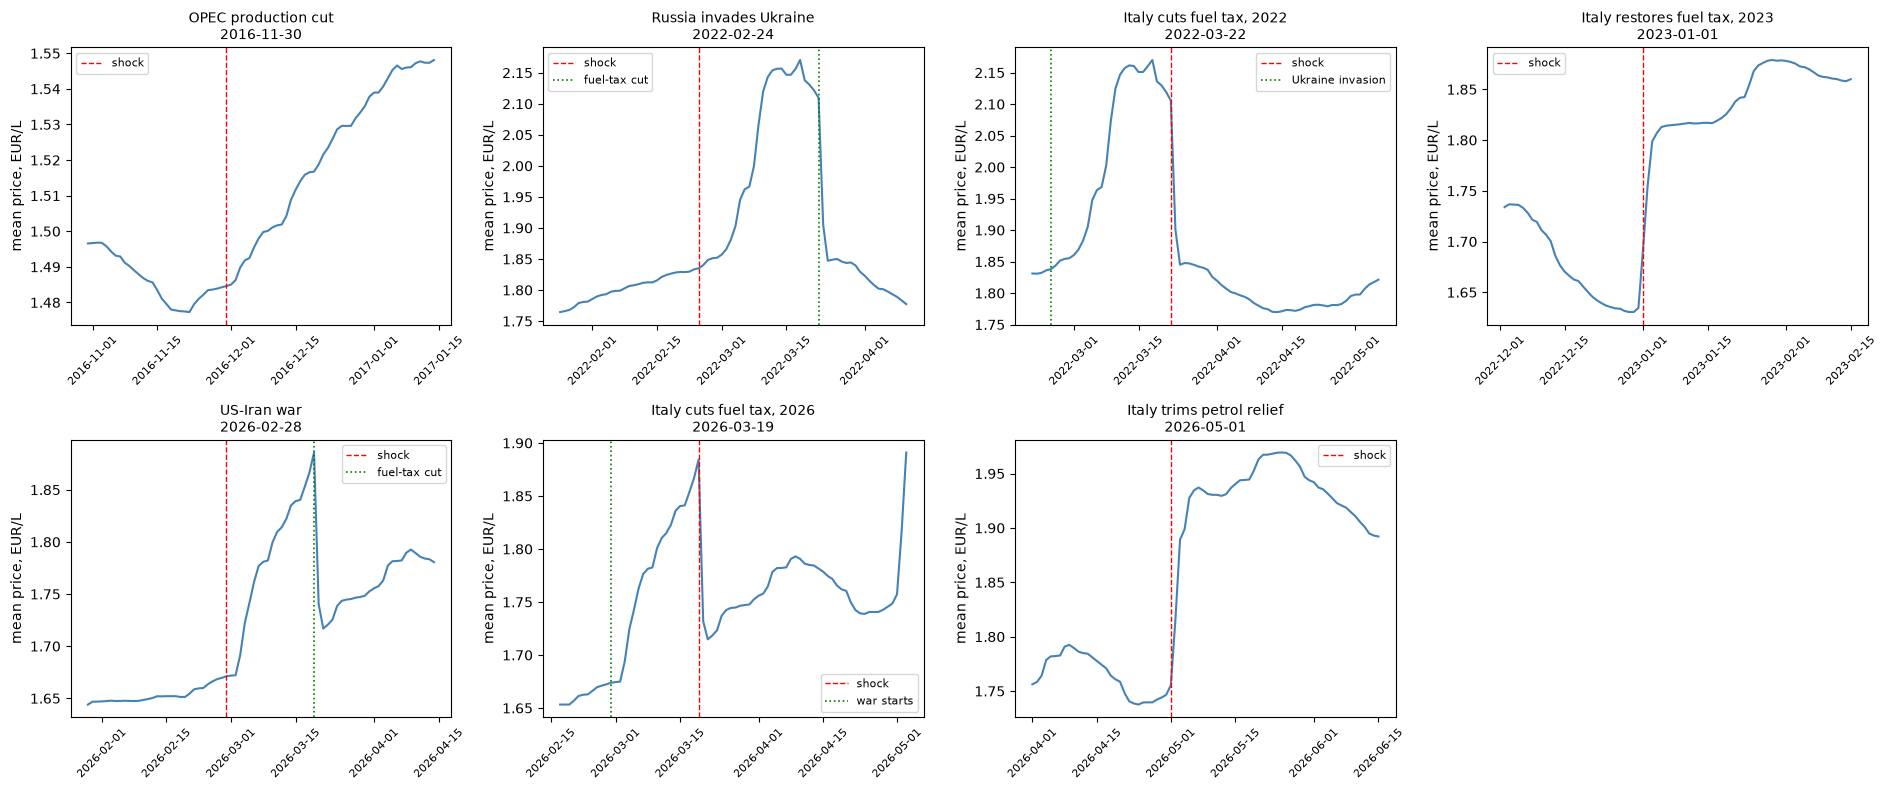

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for ax, (name, date) in zip(axes.flat, SHOCKS.items()):
    s = pd.Timestamp(date)
    trend = panels[name].mean(axis=1)
    ax.plot(trend.index, trend.values, color='steelblue')
    ax.axvline(s, color='red', linestyle='--', linewidth=1, label='shock')
    if name in CONTEXT:
        when, label = CONTEXT[name]
        ax.axvline(pd.Timestamp(when), color='green', linestyle=':', linewidth=1.2, label=label)
    ax.set_title(f'{name}\n{date}', fontsize=10)
    ax.set_ylabel('mean price, EUR/L')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
for ax in axes.flat[len(SHOCKS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

The OPEC cut nudged the average up ~4 cents/L over several weeks; everything else
is faster and bigger. The two wars have the same shape - a flat run, a
near-vertical climb starting a few days after the fighting, then a cliff down
when Italy's excise cut lands (green line). The two "Italy cuts fuel tax" panels
are that same cliff seen head-on. The January-2023 expiry and the May-2026 petrol
roll-back are both sharp ~+15-21 cent steps.

In [4]:
def summarise(name):
    r = responses[name]
    s = pd.Timestamp(SHOCKS[name])
    # 3-day rolling median kills one-day scrape glitches; window matches the
    # per-station react window so a later event in the panel can't contaminate it
    trend = panels[name].mean(axis=1).rolling(3, center=True, min_periods=1).median()
    window = trend.loc[s: min(s + pd.Timedelta(days=REACT_DAYS), trend.index[-1])] - trend.loc[s]
    moved = r['lag_days'].notna()
    return {
        'national move to extreme (c/L)': round(window.loc[window.abs().idxmax()] * 100, 1),
        'moved within 3 days (%)': round((r['lag_days'] <= 3).mean() * 100),
        'moved within 7 days (%)': round((r['lag_days'] <= 7).mean() * 100),
        'never moved in 21 days (%)': round((~moved).mean() * 100),
        'median lag (days)': r['lag_days'].median(),
        'median peak move (c/L)': round(r['peak_move'].median() * 100, 1),
        'peak move IQR (c/L)': (round(r['peak_move'].quantile(.25) * 100, 1),
                                round(r['peak_move'].quantile(.75) * 100, 1)),
    }


pd.DataFrame({name: summarise(name) for name in SHOCKS}).T

,national move to extreme (c/L),moved within 3 days (%),moved within 7 days (%),never moved in 21 days (%),median lag (days),median peak move (c/L),peak move IQR (c/L)
OPEC production cut,3.7,40,64,17,4.0,4.0,"(2.0, 6.0)"
Russia invades Ukraine,32.1,55,83,9,2.0,35.0,"(30.0, 40.0)"
"Italy cuts fuel tax, 2022",-33.1,88,93,5,1.0,-35.0,"(-40.0, -31.0)"
"Italy restores fuel tax, 2023",15.0,74,83,4,2.0,19.3,"(5.6, 22.0)"
US-Iran war,19.5,56,97,2,3.0,22.0,"(17.5, 26.0)"
"Italy cuts fuel tax, 2026",-14.8,94,97,2,1.0,-21.0,"(-24.4, -18.0)"
Italy trims petrol relief,21.2,81,97,2,2.0,22.3,"(21.0, 24.0)"


## How fast, and how uniform?

Cumulative share of sampled stations that have repriced by day *t* after the shock.

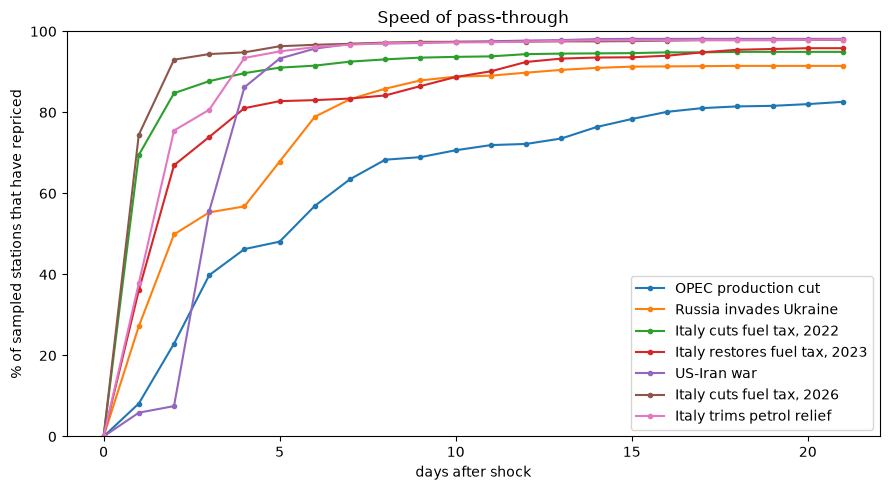

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
days = np.arange(0, REACT_DAYS + 1)
for name in SHOCKS:
    lag = responses[name]['lag_days']
    ax.plot(days, [(lag <= d).mean() * 100 for d in days], marker='.', label=name)
ax.set_xlabel('days after shock')
ax.set_ylabel('% of sampled stations that have repriced')
ax.set_ylim(0, 100)
ax.legend()
ax.set_title('Speed of pass-through')
plt.tight_layout()
plt.show()

## Does brand or road type predict the response?

`02_price_drivers.ipynb` found brand and motorway location drive the price
*level*. Do they also drive the *reaction* - who moves first, who moves furthest?
Regress `lag_days` and `peak_move` on station type and a supermarket-brand flag,
for every shock except the small OPEC one.

In [6]:
attrs = con.execute("SELECT station_id, brand_name, station_type FROM station").df()
SUPERMARKET_BRANDS = ['CONAD', 'Enercoop', 'Auchan', 'Iper Station', 'COOP', 'Carrefour']

for name in [n for n in SHOCKS if n != 'OPEC production cut']:
    r = responses[name].merge(attrs, on='station_id', how='left')
    r['supermarket'] = r['brand_name'].isin(SUPERMARKET_BRANDS)
    r = r[r['lag_days'].notna()]
    print(f"--- {name}  (n = {len(r)}) ---")
    for y in ['lag_days', 'peak_move']:
        m = smf.ols(f'{y} ~ C(station_type) + supermarket', data=r).fit()
        sm = m.params['supermarket[T.True]'] * (100 if y == 'peak_move' else 1)
        unit = 'c/L' if y == 'peak_move' else 'days'
        print(f"  {y:10}: R^2 {m.rsquared:.3f}   supermarket {sm:+.2f} {unit} "
              f"(p = {m.pvalues['supermarket[T.True]']:.2f})")
    print()

--- Russia invades Ukraine  (n = 1480) ---
  lag_days  : R^2 0.002   supermarket -1.09 days (p = 0.18)
  peak_move : R^2 0.003   supermarket -5.15 c/L (p = 0.06)

--- Italy cuts fuel tax, 2022  (n = 1536) ---
  lag_days  : R^2 0.001   supermarket -0.15 days (p = 0.79)
  peak_move : R^2 0.000   supermarket +0.95 c/L (p = 0.77)

--- Italy restores fuel tax, 2023  (n = 1496) ---
  lag_days  : R^2 0.001   supermarket -1.77 days (p = 0.15)
  peak_move : R^2 0.006   supermarket +8.51 c/L (p = 0.01)

--- US-Iran war  (n = 1636) ---
  lag_days  : R^2 0.000   supermarket -0.05 days (p = 0.91)
  peak_move : R^2 0.002   supermarket +1.34 c/L (p = 0.52)

--- Italy cuts fuel tax, 2026  (n = 1622) ---
  lag_days  : R^2 0.001   supermarket -0.04 days (p = 0.92)
  peak_move : R^2 0.004   supermarket +0.95 c/L (p = 0.64)

--- Italy trims petrol relief  (n = 1640) ---
  lag_days  : R^2 0.000   supermarket -0.28 days (p = 0.60)
  peak_move : R^2 0.013   supermarket +0.39 c/L (p = 0.79)



## Interpretation

**A mandated tax change passes through almost instantly.** Both of Italy's
emergency excise cuts took effect on a fixed legal date, and ~90% of stations
had repriced within three days (median lag 1 day) - the fastest, most uniform
response of any event here; the March-2026 cut, with the war keeping everyone
glued to prices, reached 94%. The expiry and petrol roll-back, mixed in with
moving crude, were a little slower (~75-80% in three days) but still quick.

**A war is nearly as fast, and no more selective.** For both Ukraine and Iran,
80-95% of stations repriced within a week of the fighting starting (median 2-3
days) and almost none sat still. Only the OPEC decision was genuinely slow -
two-thirds at a week, a sixth still unmoved at three. A scheduled cartel decision
seeps into retail prices; an invasion or a tax change is passed through at once.

**Events differ in size and persistence, not speed.** Ukraine ran ~+32 cents/L
before its excise cut reversed almost exactly that much; the Iran spike was ~+20
and was cut short the same way three weeks in. The expiry and petrol roll-back
are sharp ~+15-21 cent steps that stuck. Where nearly every station made a
similar large move (the cuts, the wars) the peak-move spread is tight (IQR ~10
cents wide); the expiry and roll-back have a longer tail of stations that barely
moved.

**That spread is idiosyncratic.** The regressions explain almost none of it -
R^2 below 0.02 for every shock, and the supermarket coefficient changes sign
between events. Neither supermarket branding nor motorway location reliably
predicts who repriced first or furthest. Whatever makes one station jump 15
cents and its neighbour 35 isn't in the data here - wholesale supply contracts,
local competition, operator behaviour.

**Caveats.** The `station` table carries only current rows, so the OPEC panel
misses stations that have since closed. `peak_move` is over a fixed 21-day
window, so a station still mid-adjustment at day 21 is undercounted. The sample
is drawn fresh each run, so exact figures shift a little.